In [9]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

import sys
import os

ROOT = os.path.abspath("..")
sys.path.append(ROOT)

from src.oracles import *
from src.optimization import *
from src.plot_trajectory_2d import *
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time
from scipy.linalg import cho_factor, cho_solve, LinAlgError


In [ ]:
def newton_modified(
    oracle,
    x_0,
    tolerance=1e-5,
    max_iter=100,
    line_search_options=None,
    trace=False,
    display=False,
    hessian_fix='none',
    gamma_init=1e-5,
    spectral_eps=1e-5
):
    start_time = time.perf_counter()
    history = defaultdict(list) if trace else None
    line_search_tool = get_line_search_tool(line_search_options)
    x_k = np.copy(x_0)
    update_history(oracle, x_k, history, start_time, trace)
    previous_alpha = None
    gamma = gamma_init

    for k in range(max_iter):
        try:
            o = oracle(x_k)
            g = o.grad()
            H = o.hess()

            if hessian_fix == 'gamma_shift':
                success = False
                attempt = 0
                while not success:
                    try:
                        H_mod = H + gamma * np.eye(H.shape[0])
                        c, low = cho_factor(H_mod, lower=True)
                        d_k = cho_solve((c, low), -g)
                        success = True
                    except LinAlgError:
                        gamma *= 10
                        attempt += 1
                        if attempt > 20:
                            raise LinAlgError("Cannot factor H + gamma*I")
                gamma = max(gamma / 10, gamma_init)
                if trace:
                    history['gamma'].append(gamma)

            elif hessian_fix == 'spectral':
                eigenvals, eigenvecs = np.linalg.eigh(H)
                eigenvals_clamped = np.maximum(eigenvals, spectral_eps)
                H_mod = eigenvecs @ np.diag(eigenvals_clamped) @ eigenvecs.T
                c, low = cho_factor(H_mod, lower=True)
                d_k = cho_solve((c, low), -g)

            else:
                c, low = cho_factor(H, lower=True)
                d_k = cho_solve((c, low), -g)

        except LinAlgError:
            return x_k, 'newton_direction_error', history
        except Exception:
            return x_k, 'computational_error', history

        try:
            step_size = line_search_tool.line_search(oracle, x_k, d_k, previous_alpha)
            if (np.any(np.isnan(d_k)) or np.any(np.isinf(d_k)) or
                step_size is None or np.isnan(step_size) or np.isinf(step_size)):
                return x_k, 'computational_error', history
            previous_alpha = step_size
            x_k += step_size * d_k
            if (np.any(np.isnan(x_k)) or np.any(np.isinf(x_k)) or
                oracle(x_k).func() is None or
                np.isnan(oracle(x_k).func()) or
                np.isinf(oracle(x_k).func())):
                return x_k, 'computational_error', history
        except Exception:
            return x_k, 'computational_error', history

        update_history(oracle, x_k, history, start_time, trace)
        if stop_criterion(oracle, x_k, x_0, tolerance):
            return x_k, 'success', history

    return x_k, 'iterations_exceeded', history

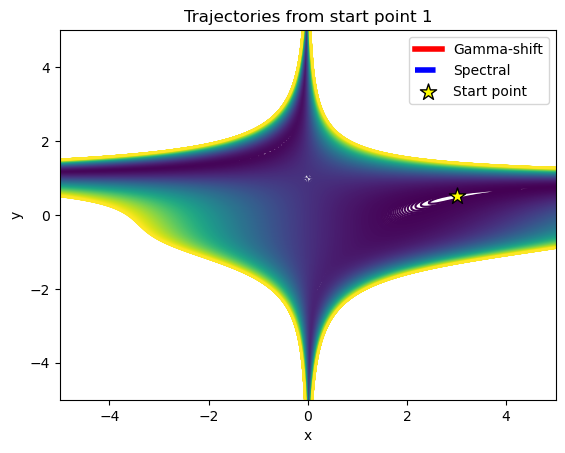

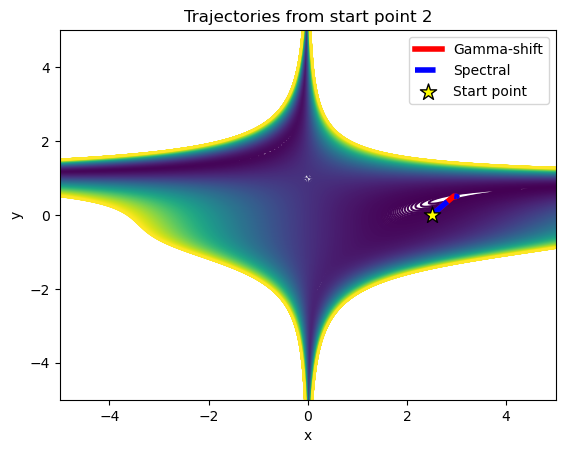

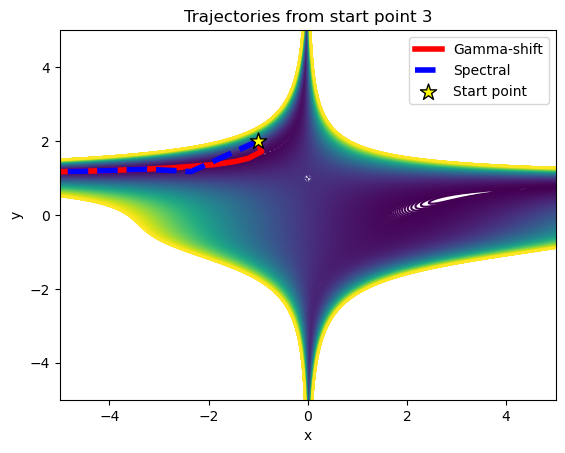

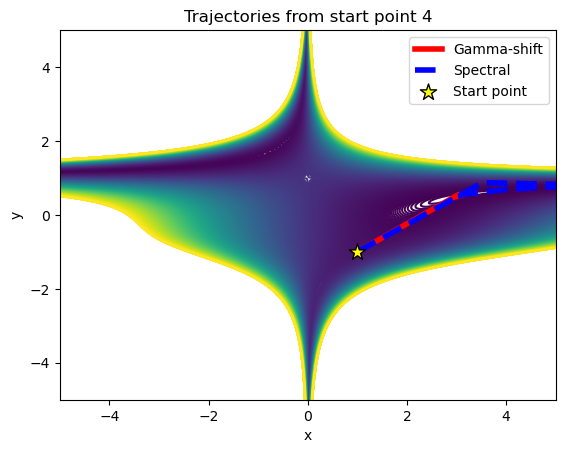

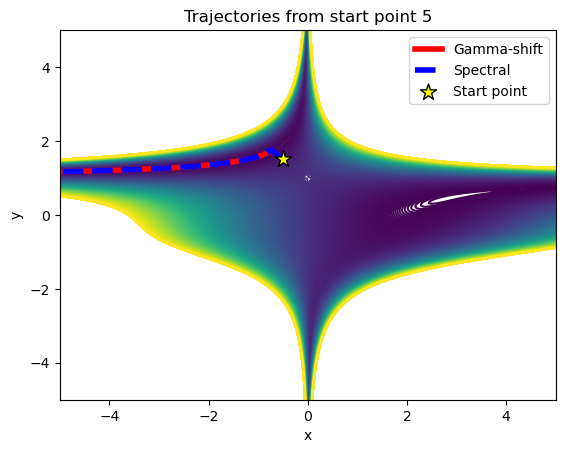

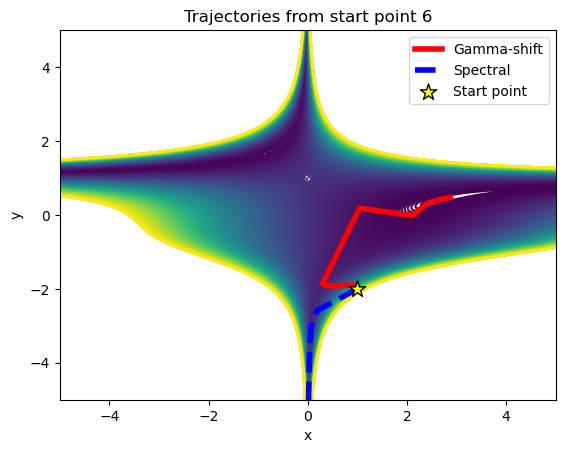

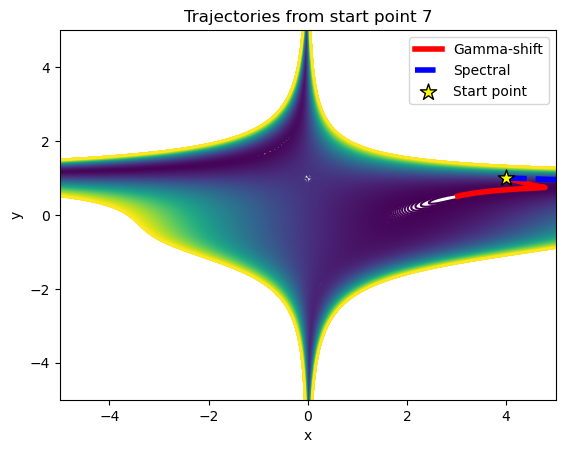

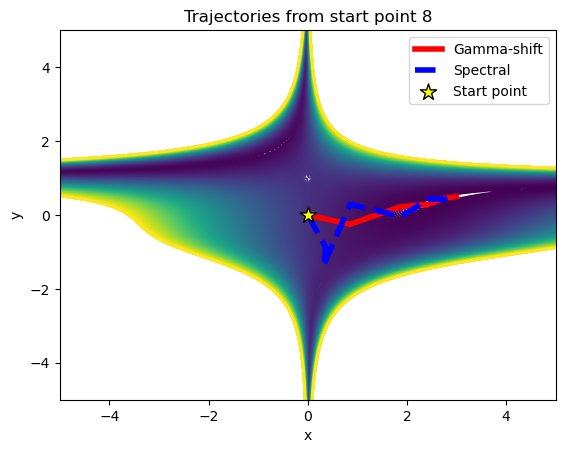

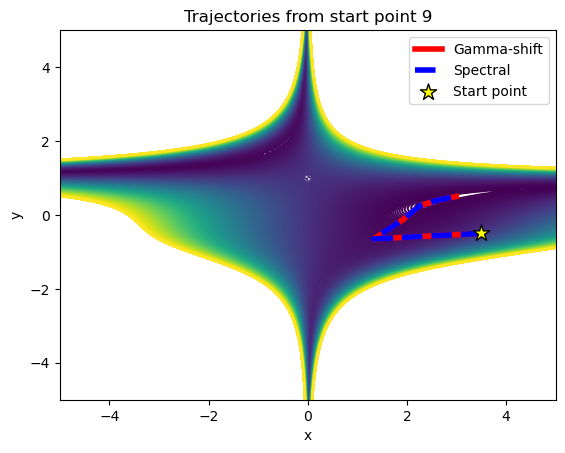

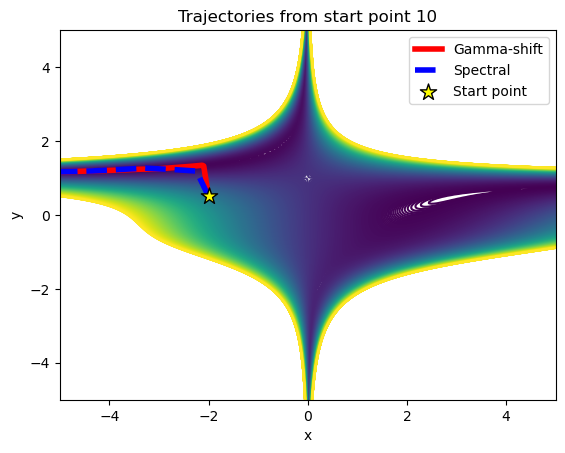

In [ ]:
oracle = NonConvexOracle()

start_points = [
    np.array([3.0, 0.5]),
    np.array([2.5, 0.0]),
    np.array([-1.0, 2.0]),
    np.array([1.0, -1.0]),
    np.array([-0.5, 1.5]),
    np.array([1.0, -2.0]),
    np.array([4.0, 1.0]),
    np.array([0.0, 0.0]),
    np.array([3.5, -0.5]),
    np.array([-2.0, 0.5])
]

max_iter = 50
tolerance = 1e-6

colors = ['r', 'b']

x_range = [-5, 5]
y_range = [-5, 5]

X = np.linspace(x_range[0], x_range[1], 300)
Y = np.linspace(y_range[0], y_range[1], 300)
XX, YY = np.meshgrid(X, Y)
ZZ = np.array([oracle.func(np.array([xi, yi])) for xi, yi in zip(np.ravel(XX), np.ravel(YY))])
ZZ = ZZ.reshape(XX.shape)

for i, x0 in enumerate(start_points):
    x_star_gamma, msg_gamma, hist_gamma = newton_modified(
        oracle,
        x0,
        max_iter=max_iter,
        tolerance=tolerance,
        trace=True,
        hessian_fix='gamma_shift',
        gamma_init=1e-3
    )
    x_star_spec, msg_spec, hist_spec = newton_modified(
        oracle,
        x0,
        max_iter=max_iter,
        tolerance=tolerance,
        trace=True,
        hessian_fix='spectral',
        spectral_eps=1e-5
    )

    ZZ_min, ZZ_max = np.min(ZZ), np.max(ZZ)
    levels = np.linspace(0, 100, 1000)
    plt.contour(XX, YY, ZZ, levels=levels, cmap='viridis')

    plt.plot(*np.array(hist_gamma['x']).T, color=colors[0], lw=4, label='Gamma-shift')
    plt.plot(*np.array(hist_spec['x']).T, color=colors[1], lw=4, ls='--', label='Spectral')

    plt.scatter(*x0, color='yellow', edgecolor='black', s=150, marker='*', label='Start point', zorder=10)

    plt.xlim(x_range)
    plt.ylim(y_range)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Trajectories from start point {i+1}')
    plt.legend()
    plt.show()

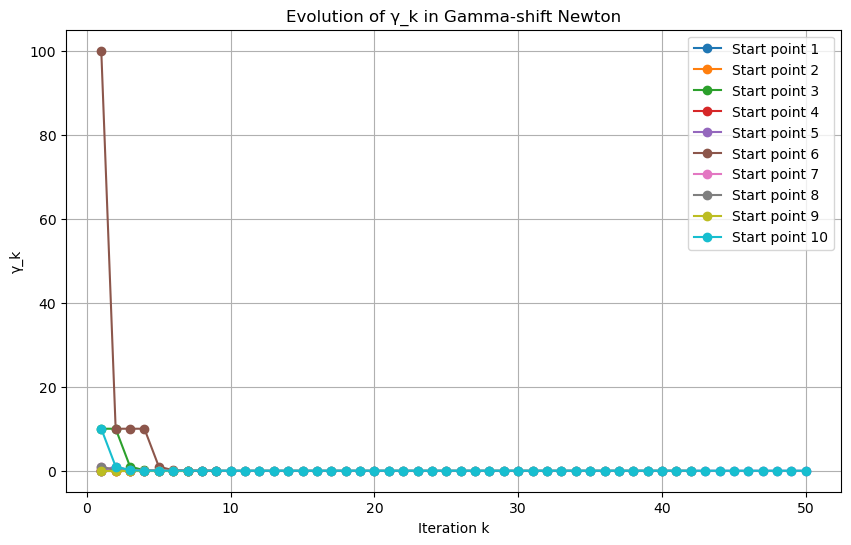

In [ ]:
plt.figure(figsize=(10, 6))

for i, x0 in enumerate(start_points):
    _, _, hist_gamma = newton_modified(
        oracle,
        x0,
        max_iter=max_iter,
        tolerance=tolerance,
        trace=True,
        hessian_fix='gamma_shift',
        gamma_init=1e-3
    )
    
    gamma_vals = hist_gamma['gamma']
    plt.plot(range(1, len(gamma_vals)+1), gamma_vals, '-o', label=f'Start point {i+1}')

plt.xlabel('Iteration k')
plt.ylabel('γ_k')
plt.title('Evolution of γ_k in Gamma-shift Newton')
plt.grid(True)
plt.legend()
plt.show()

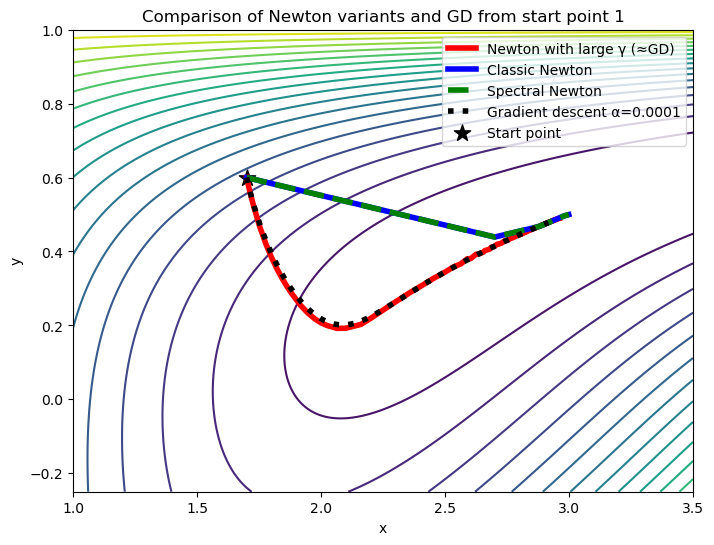

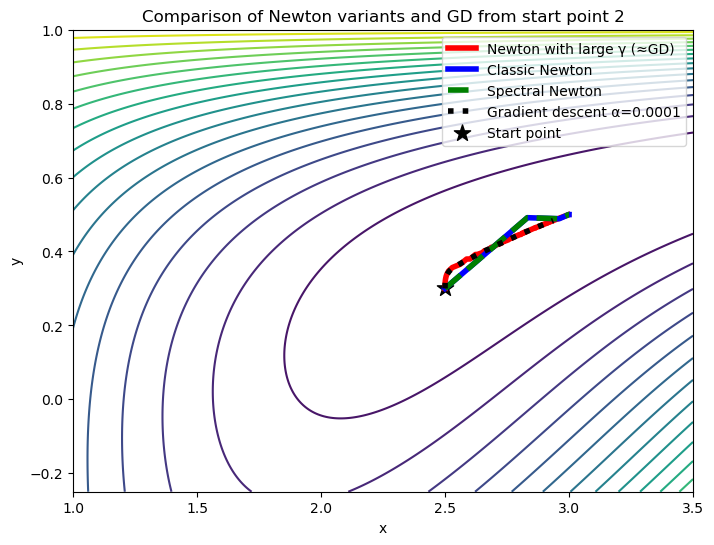

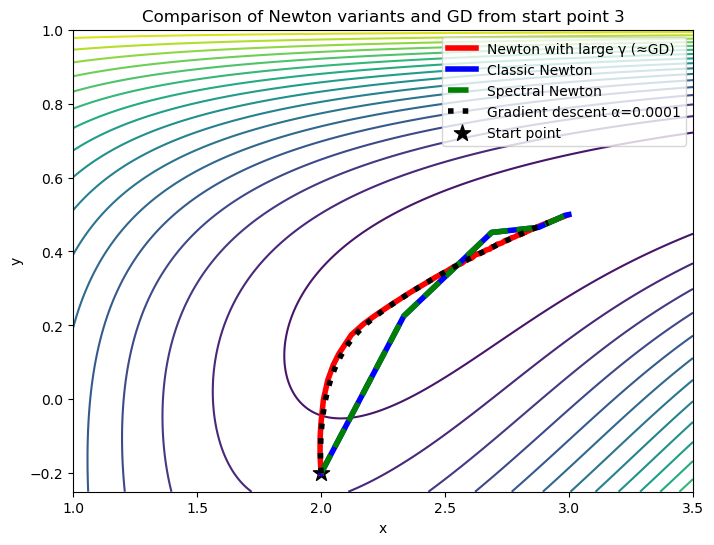

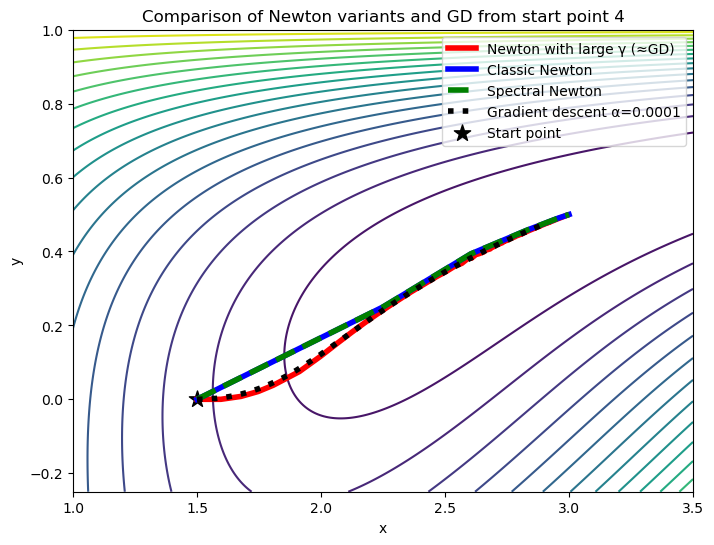

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

oracle = NonConvexOracle()

start_points = [
    np.array([1.7, 0.6]),
    np.array([2.5, 0.3]),
    np.array([2.0, -0.2]),
    np.array([1.5, 0.0]),
]

max_iter = 50000
tolerance = 1e-6
alpha_gd = 0.0001
num_levels = 50

def gradient_descent(oracle, x0, alpha=0.01, max_iter=50):
    x_k = np.copy(x0)
    history = [x_k.copy()]
    for k in range(max_iter):
        g = oracle(x_k).grad()
        x_k = x_k - alpha * g
        history.append(x_k.copy())
    return x_k, history

colors = ['r', 'b', 'g', 'black']
x_range = [1, 3.5]
y_range = [-0.25, 1]

X = np.linspace(x_range[0], x_range[1], 300)
Y = np.linspace(y_range[0], y_range[1], 300)
XX, YY = np.meshgrid(X, Y)
ZZ = np.array([oracle.func(np.array([xi, yi])) for xi, yi in zip(np.ravel(XX), np.ravel(YY))])
ZZ = ZZ.reshape(XX.shape)

for i, x0 in enumerate(start_points):
    x_star_gamma, msg_gamma, hist_gamma = newton_modified(
        oracle, x0,
        max_iter=max_iter,
        tolerance=tolerance,
        trace=True,
        hessian_fix='gamma_shift',
        gamma_init=1 / alpha_gd
    )
    x_star_newton, msg_newton, hist_newton = newton_modified(
        oracle, x0,
        max_iter=max_iter,
        tolerance=tolerance,
        trace=True,
        hessian_fix='none'
    )
    x_star_spec, msg_spec, hist_spec = newton_modified(
        oracle, x0,
        max_iter=max_iter,
        tolerance=tolerance,
        trace=True,
        hessian_fix='spectral',
        spectral_eps=1e-5
    )
    x_star_gd, hist_gd = gradient_descent(oracle, x0, alpha=alpha_gd, max_iter=max_iter)

    plt.figure(figsize=(8, 6))
    plt.contour(XX, YY, ZZ, levels=20, cmap='viridis')

    plt.plot(*np.array(hist_gamma['x']).T, color=colors[0], lw=4, label='Newton with large γ (≈GD)')
    plt.plot(*np.array(hist_newton['x']).T, color=colors[1], lw=4, label='Classic Newton')
    plt.plot(*np.array(hist_spec['x']).T, color=colors[2], lw=4, ls='--', label='Spectral Newton')
    plt.plot(*np.array(hist_gd).T, color=colors[3], lw=4, ls=':', label=f'Gradient descent α={alpha_gd}')

    plt.scatter(*x0, color='k', marker='*', s=150, label='Start point')

    plt.xlim(x_range)
    plt.ylim(y_range)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Comparison of Newton variants and GD from start point {i+1}')
    plt.legend()
    plt.show()

In [11]:
from sklearn.datasets import load_svmlight_file


DATA_FOLDER = os.path.join(ROOT, "datasets/")

os.makedirs(DATA_FOLDER, exist_ok=True)

In [12]:
DATASETS = {
    "gisette": "gisette_scale",
    "a9a": "a9a",
    "abalone": "abalone",
    "bodyfat": "bodyfat"
}

In [13]:
loaded_datasets = {}

for name, file_name in DATASETS.items():
    file_path = os.path.join(DATA_FOLDER, file_name)
    
    print(f"Loading {name} from: {file_path}")
    
    X, y = load_svmlight_file(file_path)
    
    loaded_datasets[name] = (X, y)
    print(f"{name}: X={X.shape}, y={y.shape}")

Loading gisette from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/gisette_scale
gisette: X=(6000, 5000), y=(6000,)
Loading a9a from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/a9a
a9a: X=(32561, 123), y=(32561,)
Loading abalone from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/abalone
abalone: X=(4177, 8), y=(4177,)
Loading bodyfat from: /home/misha/Документы/ITMO/2 курс/opt/ExistanseOfNonExistentSubject/datasets/bodyfat
bodyfat: X=(252, 14), y=(252,)


In [14]:
X, y = load_svmlight_file(os.path.join(DATA_FOLDER, DATASETS['gisette']))

n_features = X.shape[1]
selected = np.random.choice(n_features, 1000, replace=False)

X_reduced = X[:, selected]

Average time per iteration:
Classic Newton: 5.894937739699526
Gamma shift (H + γI): 5.687318487399898
Spectral truncation: 6.140158587500627


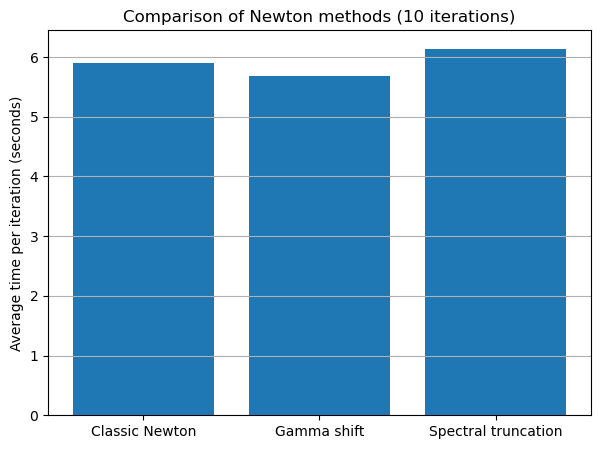

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.linalg import cho_factor, eigh, LinAlgError
from scipy.sparse import diags


regcoef = 0.0

def matvec_Ax(x):
    return X_reduced @ x

def matvec_ATx(x):
    return X_reduced.T @ x

def matmat_ATsA(s):
    return X_reduced.T @ diags(s) @ X_reduced

oracle = ExponentialLossL2Oracle(
    matvec_Ax,
    matvec_ATx,
    matmat_ATsA,
    y,
    regcoef
)


def time_newton(oracle, x, iters=10):
    """
    Classical Newton: only attempt Cholesky.
    If Hessian is not PD the factorization fails,
    but we still count the time.
    """
    start = time.perf_counter()

    for _ in range(iters):
        g = oracle.grad(x)
        H = oracle.hess(x)

        try:
            cho_factor(H)
        except LinAlgError:
            pass

    end = time.perf_counter()
    return (end - start) / iters


def time_gamma_shift(oracle, x, iters=10):
    """
    Newton with dynamic gamma shift (Levenberg–Marquardt)
    """
    start = time.perf_counter()

    for _ in range(iters):

        g = oracle.grad(x)
        H = oracle.hess(x)

        gamma = 1e-5

        while True:
            try:
                H_mod = H + gamma * np.eye(H.shape[0])
                cho_factor(H_mod)
                break
            except LinAlgError:
                gamma *= 10

    end = time.perf_counter()
    return (end - start) / iters


def time_spectral(oracle, x, iters=10):
    """
    Newton with spectral truncation
    """
    start = time.perf_counter()

    for _ in range(iters):

        g = oracle.grad(x)
        H = oracle.hess(x)

        eigvals, eigvecs = eigh(H)

        eigvals = np.maximum(eigvals, 1e-5)

        H_mod = eigvecs @ np.diag(eigvals) @ eigvecs.T

        cho_factor(H_mod)

    end = time.perf_counter()
    return (end - start) / iters


x0 = np.zeros(X_reduced.shape[1])

t_newton = time_newton(oracle, x0, 10)
t_gamma = time_gamma_shift(oracle, x0, 10)
t_spectral = time_spectral(oracle, x0, 10)

print("Average time per iteration:")
print("Classic Newton:", t_newton)
print("Gamma shift (H + γI):", t_gamma)
print("Spectral truncation:", t_spectral)


methods = [
    "Classic Newton",
    "Gamma shift",
    "Spectral truncation"
]

times = [
    t_newton,
    t_gamma,
    t_spectral
]

plt.figure(figsize=(7,5))
plt.bar(methods, times)

plt.ylabel("Average time per iteration (seconds)")
plt.title("Comparison of Newton methods (10 iterations)")
plt.grid(axis="y")

plt.show()